# Phase 3: Supervised Learning for False Positive Reduction
# Task 3.3: Tuned Random Forest

Build and tune a supervised flow-level classifier that separates benign and attack flows.

This notebook uses `StratifiedKFold` with five folds and `RandomizedSearchCV` to tune the Random Forest on the training split. The validation and test sets remain outside cross-validation so they can be used for independent evaluation.


## Setup and load the fixed flow splits

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    make_scorer
)

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data.flow_preprocessing import ATTACK_COL, BINARY_COL, FLOW_KEY_COL, TARGET_COL, build_flow_preprocessor

DATA_FOLDER = "phase3"
DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATA_FOLDER
META_PATH = DATA_DIR / "flow_split_metadata.json"

with open(META_PATH, "r") as f:
    metadata = json.load(f)

train_df = pd.read_csv(DATA_DIR / "flow_train.csv", low_memory=False)
validation_df = pd.read_csv(DATA_DIR / "flow_validation.csv", low_memory=False)
test_df = pd.read_csv(DATA_DIR / "flow_test.csv", low_memory=False)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
metadata

Train shape: (89593, 89)
Validation shape: (19199, 89)
Test shape: (19199, 89)


{'input_path': 'data/samples/flow_sample_seed1.csv',
 'seed': 1,
 'validation_size': 0.15,
 'test_size': 0.15,
 'raw_rows': 127991,
 'clean_rows': 127991,
 'feature_count': 80,
 'feature_columns': ['Src Port',
  'Dst Port',
  'Protocol',
  'Flow Duration',
  'Total Fwd Packet',
  'Total Bwd packets',
  'Total Length of Fwd Packet',
  'Total Length of Bwd Packet',
  'Fwd IAT Total',
  'Bwd IAT Total',
  'Fwd PSH Flags',
  'Bwd PSH Flags',
  'Fwd URG Flags',
  'Bwd URG Flags',
  'Fwd Header Length',
  'Bwd Header Length',
  'FIN Flag Count',
  'SYN Flag Count',
  'RST Flag Count',
  'PSH Flag Count',
  'ACK Flag Count',
  'URG Flag Count',
  'CWR Flag Count',
  'ECE Flag Count',
  'Subflow Fwd Packets',
  'Subflow Fwd Bytes',
  'Subflow Bwd Packets',
  'Subflow Bwd Bytes',
  'Fwd Act Data Pkts',
  'Fwd Packet Length Max',
  'Bwd Packet Length Max',
  'Flow IAT Max',
  'Fwd IAT Max',
  'Bwd IAT Max',
  'Packet Length Max',
  'Active Max',
  'Idle Max',
  'Fwd Packet Length Min',
  'Bwd Pa

### Verify the class distribution and split integrity

In [2]:
for name, current_df in [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]:
    print(f"{name} binary counts")
    print(current_df[BINARY_COL].value_counts())
    print()

train_keys = set(train_df[FLOW_KEY_COL])
validation_keys = set(validation_df[FLOW_KEY_COL])
test_keys = set(test_df[FLOW_KEY_COL])

print("Flow-key overlap")
print("Train and validation:", len(train_keys & validation_keys))
print("Train and test:", len(train_keys & test_keys))
print("Validation and test:", len(validation_keys & test_keys))

Train binary counts
binary_label
benign    86064
attack     3529
Name: count, dtype: int64

Validation binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Test binary counts
binary_label
benign    18443
attack      756
Name: count, dtype: int64

Flow-key overlap
Train and validation: 0
Train and test: 0
Validation and test: 0


## Random Forest feature preparation

The model uses the 80 numeric flow-behaviour features recorded in the split metadata. Labels, flow identifiers, IP addresses, timestamps, and source-file information are excluded.

Random Forest does not require feature scaling. The preprocessing pipeline therefore only:

- replaces remaining missing values with the training median;
- adds missing-value indicators where needed;
- removes constant features.

The preprocessing pipeline is fitted using the training set only.

In [3]:
feature_cols = metadata["feature_columns"]
missing_features = [col for col in feature_cols if col not in train_df.columns]

if missing_features:
    raise ValueError(f"Missing model features: {missing_features}")

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL].to_numpy()

X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET_COL].to_numpy()

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].to_numpy()

print("Input features:", len(feature_cols))
print("Training missing values:", int(X_train.isna().sum().sum()))
print("Validation missing values:", int(X_validation.isna().sum().sum()))
print("Test missing values:", int(X_test.isna().sum().sum()))

Input features: 80
Training missing values: 136
Validation missing values: 16
Test missing values: 20


## Tune Random Forest with 5-fold stratified cross-validation

The hyperparameter search uses only the training split.

`StratifiedKFold` preserves the benign-to-attack ratio in each fold. The complete preprocessing pipeline is included inside `RandomizedSearchCV`, so median imputation and constant-feature removal are fitted separately within every training fold.

The search refits the configuration with the highest mean cross-validation PR-AUC. PR-AUC is used as the main metric because attacks are the minority class. The validation and test sets are not used to select the hyperparameters.


In [4]:
RANDOM_STATE = 1
N_ITER = 12
CLASSIFICATION_THRESHOLD = 0.50

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preprocessor = build_flow_preprocessor(scale=False)
random_forest = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest)
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__class_weight": ["balanced", "balanced_subsample"],
    "model__bootstrap": [True, False]
}

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0)
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    return_train_score=False
)

start_search = time.perf_counter()
rf_search.fit(X_train, y_train)
search_time = time.perf_counter() - start_search

rf_pipeline = rf_search.best_estimator_
rf_pipeline.named_steps["model"].set_params(n_jobs=-1)

print(f"Search time: {search_time:.2f} seconds")
print(f"Best mean CV PR-AUC: {rf_search.best_score_:.4f}")
print("Best parameters:")
for name, value in rf_search.best_params_.items():
    print(f"  {name}: {value}")

processed_feature_count = rf_pipeline.named_steps["preprocessor"].named_steps["remove_constant"].get_support().sum()
print("Processed features:", processed_feature_count)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 1.8min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 1.8min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsample, model__max_depth=None, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=20, model__n_estimators=200; total time= 1.9min
[CV] END model__bootstrap=True, model__class_weight=balanced, model__max_depth=30, model__max_features=0.3, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=300; total time= 1.2min
[CV] END model__bootstrap=False, model__class_weight=balanced_subsam

### Cross-validation results

The table below shows the highest-ranked sampled configurations. The final estimator is the row with rank 1 for mean validation PR-AUC across the five folds.


In [5]:
cv_results_df = pd.DataFrame(rf_search.cv_results_)

result_columns = [
    "rank_test_pr_auc",
    "mean_test_pr_auc",
    "std_test_pr_auc",
    "mean_test_roc_auc",
    "mean_test_f1",
    "mean_test_precision",
    "mean_test_recall",
    "mean_fit_time",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "param_model__class_weight",
    "param_model__bootstrap"
]

top_cv_results = cv_results_df[result_columns].sort_values("rank_test_pr_auc").head(10)
display(top_cv_results.round(4))


,rank_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,mean_test_f1,mean_test_precision,mean_test_recall,mean_fit_time,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__class_weight,param_model__bootstrap
6,1,0.8384,0.0136,0.9696,0.7397,0.6911,0.7960,61.7259,200,None,2,2,0.3,balanced,True
0,2,0.8384,0.0146,0.9702,0.6838,0.5829,0.8274,268.3329,700,None,10,4,0.5,balanced,True
11,3,0.8368,0.0130,0.9752,0.7093,0.6339,0.8056,41.9802,300,20,5,4,log2,balanced_subsample,False
2,4,0.8367,0.0146,0.9678,0.7189,0.6470,0.8093,77.4261,300,30,10,1,0.3,balanced,True
10,5,0.8352,0.0136,0.9722,0.6207,0.4883,0.8521,107.2576,500,40,2,8,0.3,balanced,True
3,6,0.8301,0.0157,0.9553,0.7701,0.7741,0.7665,673.4988,700,None,10,1,0.5,balanced,False
8,7,0.8290,0.0155,0.9623,0.7169,0.6454,0.8068,240.0858,300,None,20,4,0.5,balanced,False
9,8,0.8288,0.0134,0.9508,0.7825,0.8242,0.7450,245.7582,500,30,5,1,0.3,balanced,False
1,9,0.8273,0.0163,0.9608,0.7330,0.6842,0.7900,108.1537,200,None,20,1,0.3,balanced_subsample,False
7,10,0.8262,0.0174,0.9733,0.6085,0.4773,0.8399,126.0301,300,10,2,1,0.3,balanced_subsample,False


## Evaluate the tuned Random Forest

In [6]:
def evaluate_binary_classifier(name, y_true, scores, threshold, prediction_time):
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "alerts": int(y_pred.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "prediction_time_sec": prediction_time
    }

    return result, y_pred

start_validation = time.perf_counter()
validation_scores = rf_pipeline.predict_proba(X_validation)[:, 1]
validation_prediction_time = time.perf_counter() - start_validation

start_test = time.perf_counter()
test_scores = rf_pipeline.predict_proba(X_test)[:, 1]
test_prediction_time = time.perf_counter() - start_test

validation_metrics, validation_pred = evaluate_binary_classifier(
    "Validation", y_validation, validation_scores, CLASSIFICATION_THRESHOLD, validation_prediction_time
)
test_metrics, test_pred = evaluate_binary_classifier(
    "Test", y_test, test_scores, CLASSIFICATION_THRESHOLD, test_prediction_time
)

metrics_df = pd.DataFrame([validation_metrics, test_metrics])
display(metrics_df.round(4))

,dataset,threshold,accuracy,precision,recall,f1,specificity,fpr,fnr,roc_auc,pr_auc,alerts,tn,fp,fn,tp,prediction_time_sec
0,Validation,0.5,0.9791,0.6961,0.8333,0.7586,0.9851,0.0149,0.1667,0.9699,0.8608,905,18168,275,126,630,0.1759
1,Test,0.5,0.9787,0.6973,0.8135,0.7509,0.9855,0.0145,0.1865,0.9678,0.8519,882,18176,267,141,615,0.0977


### Confusion matrices

The selected hyperparameters are evaluated on the untouched validation set and then on the test set. The probability threshold remains at 0.5 so that hyperparameter tuning and threshold tuning remain separate experiments.


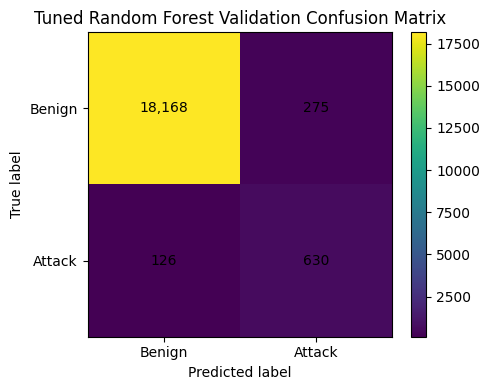

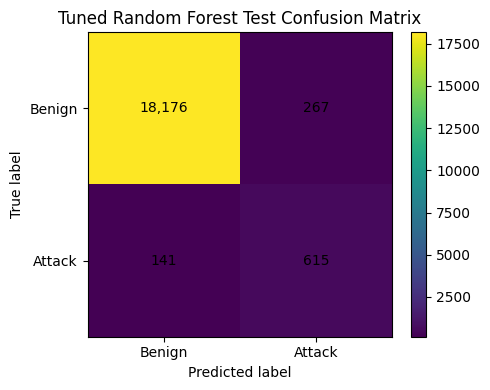

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_validation, validation_pred, "Tuned Random Forest Validation Confusion Matrix")
plot_confusion_matrix(y_test, test_pred, "Tuned Random Forest Test Confusion Matrix")

### Test classification report

In [8]:
report = classification_report(
    y_test,
    test_pred,
    target_names=["Benign", "Attack"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
display(report_df.round(4))

,precision,recall,f1-score,support
Benign,0.9923,0.9855,0.9889,18443.0000
Attack,0.6973,0.8135,0.7509,756.0000
accuracy,0.9787,0.9787,0.9787,0.9787
macro avg,0.8448,0.8995,0.8699,19199.0000
weighted avg,0.9807,0.9787,0.9795,19199.0000


### Results by traffic type

,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,18443,18176,267,98.55
DDoS-HTTP Flood,147,143,4,97.28
DoS-HTTP Flood,153,141,12,92.16
DNS Spoofing,152,89,63,58.55
Brute Force,146,113,33,77.40
XSS,158,129,29,81.65


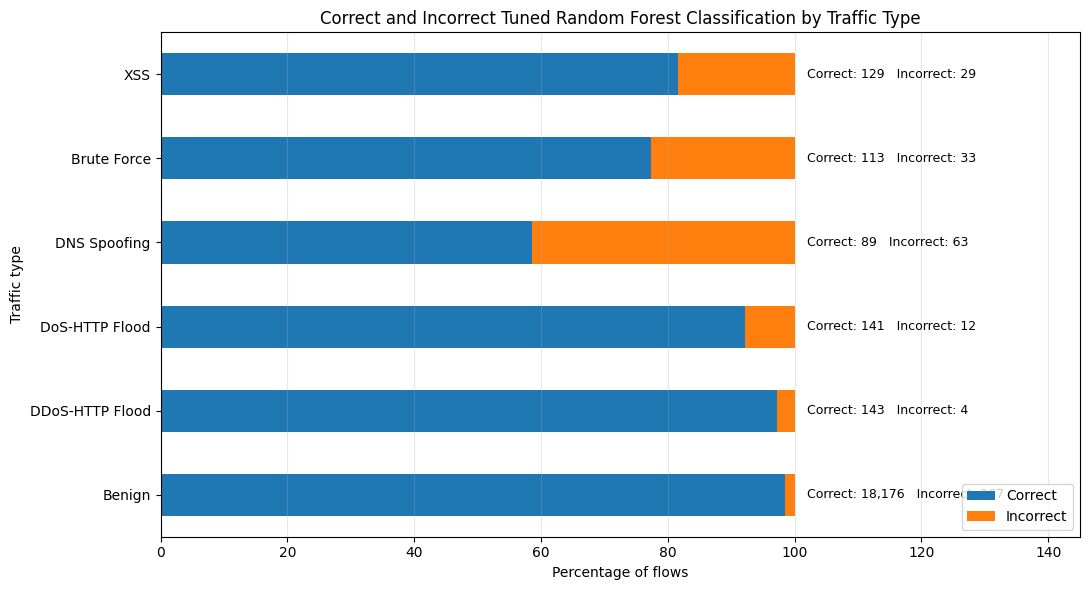

In [9]:
type_results = test_df[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of flows")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Tuned Random Forest Classification by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### ROC and precision-recall curves

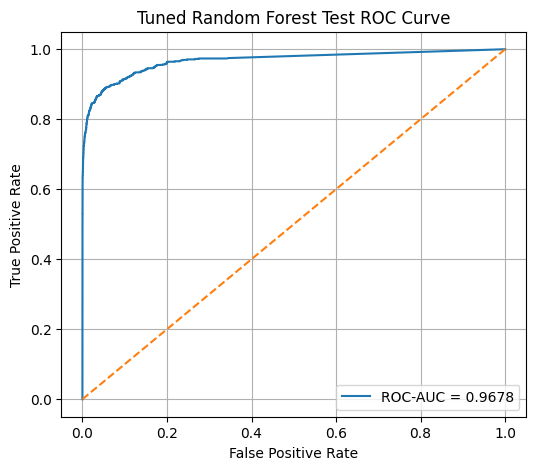

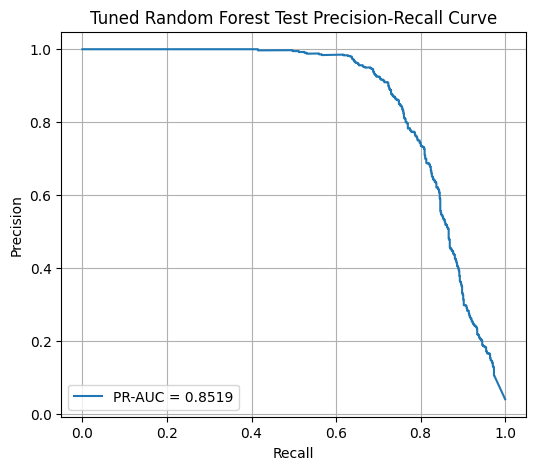

In [10]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curve(y_test, test_scores, "Tuned Random Forest Test ROC Curve")
plot_precision_recall_curve(y_test, test_scores, "Tuned Random Forest Test Precision-Recall Curve")

## Tuned model feature importance

Feature importance measures how much each processed feature reduces impurity across the trees in the best cross-validation configuration.

,feature,importance
0,Flow IAT Max,0.090801
1,Flow Bytes/s,0.079652
2,Src Port,0.052498
3,Flow Duration,0.044037
4,Flow Packets/s,0.042496
5,Dst Port,0.042149
6,FWD Init Win Bytes,0.036699
7,Bwd Packet Length Max,0.035314
8,Bwd Packets/s,0.029149
9,Flow IAT Mean,0.028702


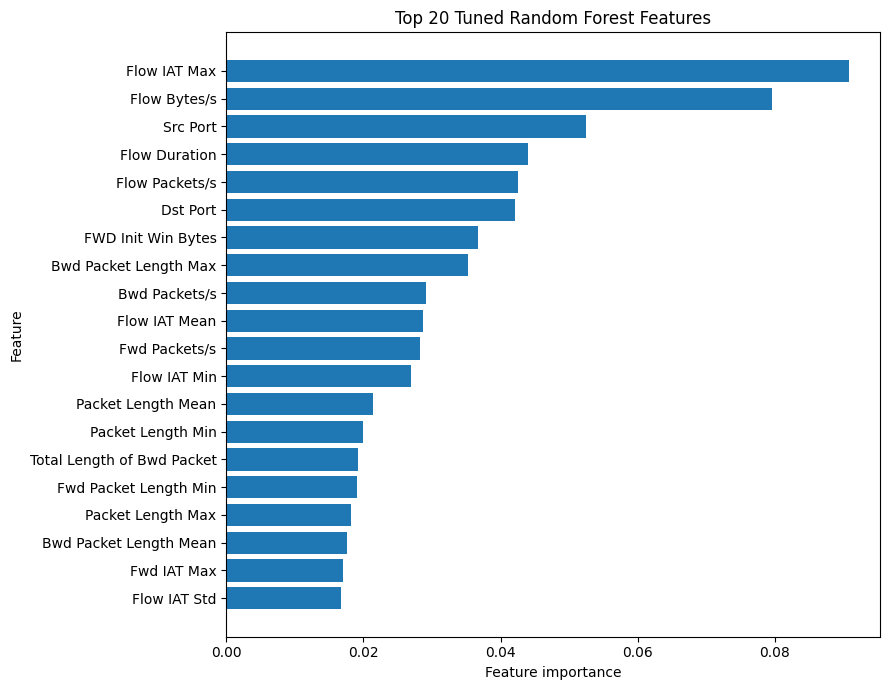

In [11]:
processed_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out(feature_cols)
feature_importance = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

plot_importance = importance_df.head(20).sort_values("importance")
plt.figure(figsize=(9, 7))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Tuned Random Forest Features")
plt.tight_layout()
plt.show()

## Save the tuned results

In [12]:
RESULTS_DIR = PROJECT_ROOT / "reports" / "phase3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_output = metrics_df.copy()
metrics_output.insert(0, "model", "Random Forest Tuned")
metrics_output["search_time_sec"] = search_time
metrics_output["refit_time_sec"] = rf_search.refit_time_
metrics_output.to_csv(RESULTS_DIR / "random_forest_tuned_metrics.csv", index=False)

importance_df.to_csv(RESULTS_DIR / "random_forest_tuned_feature_importance.csv", index=False)
cv_results_df.to_csv(RESULTS_DIR / "random_forest_random_search_results.csv", index=False)

best_parameters = {
    "best_cv_pr_auc": rf_search.best_score_,
    "search_time_sec": search_time,
    "refit_time_sec": rf_search.refit_time_,
    "n_iter": N_ITER,
    "cv_folds": cv.get_n_splits(),
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "best_params": rf_search.best_params_
}

with open(RESULTS_DIR / "random_forest_best_parameters.json", "w") as f:
    json.dump(best_parameters, f, indent=2)

prediction_cols = [FLOW_KEY_COL, ATTACK_COL, BINARY_COL, TARGET_COL]
test_predictions = test_df[prediction_cols].copy()
test_predictions["attack_probability"] = test_scores
test_predictions["prediction"] = test_pred
test_predictions.to_csv(RESULTS_DIR / "random_forest_tuned_test_predictions.csv", index=False)

print("Saved tuned Random Forest results to:", RESULTS_DIR)


Saved tuned Random Forest results to: /Users/yuanmingwang/Documents/doc/uvic/Summer 2026/ECE 597 Capstone Project/multi-stage-iot-ids/reports/phase3


## Final tuned Random Forest summary

In [13]:
test_row = metrics_df.loc[metrics_df["dataset"] == "Test"].iloc[0]

print("Final tuned Random Forest test results")
print("--------------------------------------")
print(f"Best mean CV PR-AUC: {rf_search.best_score_:.4f}")
print(f"Accuracy: {test_row['accuracy']:.4f}")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Search time: {search_time:.2f} seconds")
print(f"Best-model refit time: {rf_search.refit_time_:.2f} seconds")
print(f"Test prediction time: {test_prediction_time:.2f} seconds")

print()
print("Best hyperparameters")
for name, value in rf_search.best_params_.items():
    print(f"{name}: {value}")

print()
print("Correct classification rate by traffic type")
for attack_type in type_order:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")


Final tuned Random Forest test results
--------------------------------------
Best mean CV PR-AUC: 0.8384
Accuracy: 0.9787
Precision: 0.6973
Recall: 0.8135
F1-score: 0.7509
ROC-AUC: 0.9678
PR-AUC: 0.8519
FPR: 0.0145
FNR: 0.1865
Search time: 1376.16 seconds
Best-model refit time: 38.20 seconds
Test prediction time: 0.10 seconds

Best hyperparameters
model__n_estimators: 200
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: 0.3
model__max_depth: None
model__class_weight: balanced
model__bootstrap: True

Correct classification rate by traffic type
Benign: 98.55%
DDoS-HTTP Flood: 97.28%
DoS-HTTP Flood: 92.16%
DNS Spoofing: 58.55%
Brute Force: 77.40%
XSS: 81.65%
